# Classification Algorithms

**Goal**: Classify examples into distinct classes (categories).

We will use the Titanic dataset to predict who survived. We'll handle categorical data, build multiple classifiers, and compare them!

### 1. Load the Dataset

We will load the Titanic dataset which actually contains both numeric and text (categorical) data!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']].dropna()
df.head()

,survived,pclass,sex,age,fare,embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


### 2. What is One-Hot Encoding?

Machine learning models need numbers, not words like 'male' or 'female'. One-hot encoding creates a new binary (0 or 1) column for each category!

In [2]:
sample = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Red']})
print("Original:\n", sample)
print("\nOne-Hot Encoded:\n", pd.get_dummies(sample, columns=['Color']))

Original:
    Color
0    Red
1   Blue
2  Green
3    Red

One-Hot Encoded:
    Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True


### 3. Encoding Categorical Features in Our Dataset

Let's convert `sex` and `embarked`! We use `drop_first=True` to avoid redundant columns (dummy variable trap).

In [3]:
df_encoded = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)
df_encoded.head()

,survived,pclass,age,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,7.2500,True,False,True
1,1,1,38.0,71.2833,False,False,False
2,1,3,26.0,7.9250,False,False,True
3,1,1,35.0,53.1000,False,False,True
4,0,3,35.0,8.0500,True,False,True


### 4. Split into Features (X) and Target (y)

In [4]:
X = df_encoded.drop(columns=['survived'])
y = df_encoded['survived']

### 5. Train/Test Split

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (569, 6)
Test size: (143, 6)


### 6. Baseline Model: Logistic Regression

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train)

y_pred_log = model_log.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", acc_log)

Logistic Regression Accuracy: 0.7622377622377622


Let's look at the full classification report:

In [8]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80        85
           1       0.71      0.69      0.70        58

    accuracy                           0.76       143
   macro avg       0.75      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



### 7. Decision Tree

Let's build a tree and visually plot it!

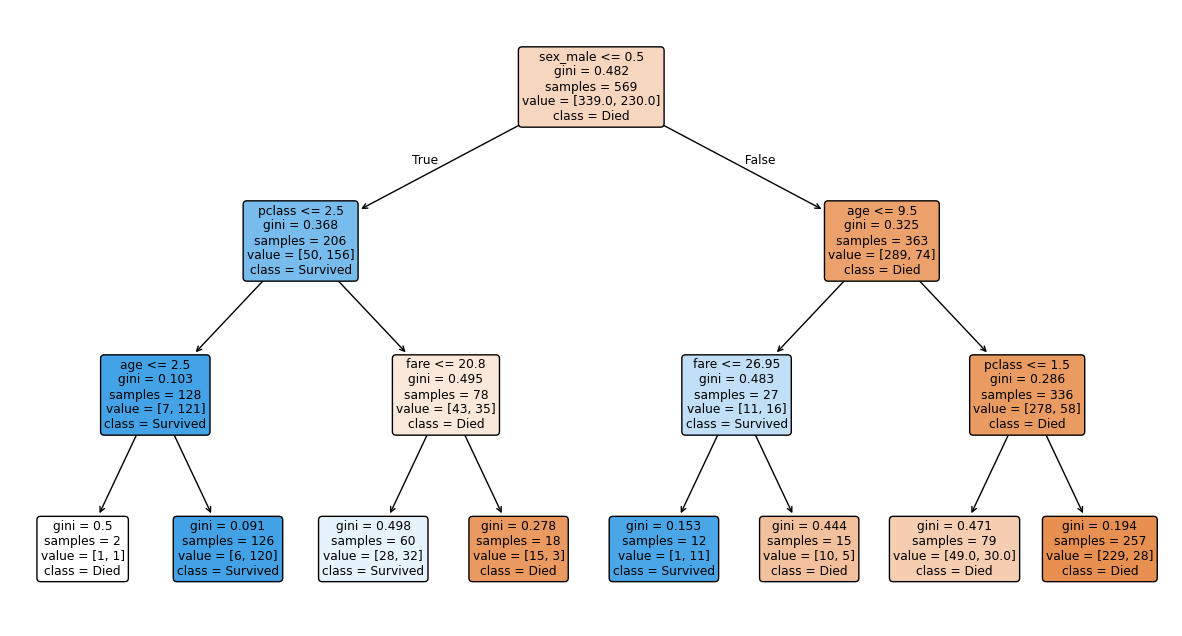

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

model_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
model_tree.fit(X_train, y_train)

y_pred_tree = model_tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)

plt.figure(figsize=(15, 8))
plot_tree(model_tree, feature_names=X.columns, class_names=['Died', 'Survived'], filled=True, rounded=True)
plt.show()

### 8. Random Forest (Bagging Ensemble)

In [10]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.7902097902097902


Random Forest can tell us which features were most important:

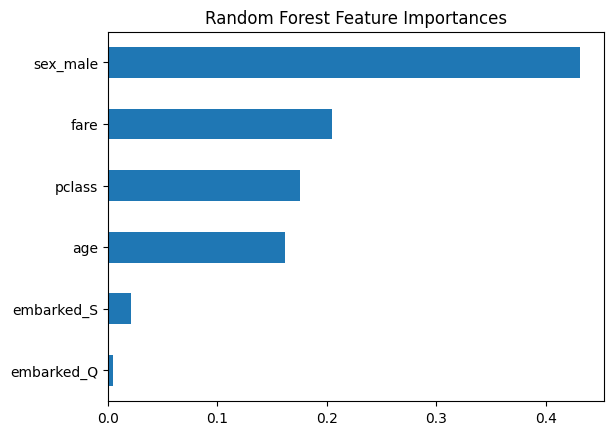

In [11]:
rf_importances = pd.Series(model_rf.feature_importances_, index=X.columns).sort_values()
rf_importances.plot(kind='barh', title='Random Forest Feature Importances')
plt.show()

### 9. Gradient Boosting (Boosting Ensemble)

In [12]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
model_gb.fit(X_train, y_train)

y_pred_gb = model_gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", acc_gb)

Gradient Boosting Accuracy: 0.7832167832167832


### 10. Summary Comparison

Let's chart all our accuracies!

In [13]:
results_clf = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [acc_log, acc_tree, acc_rf, acc_gb],
    'Type': ['Linear', 'Single Tree', 'Bagging Ensemble', 'Boosting Ensemble']
})

results_clf.sort_values('Accuracy', ascending=False)

,Model,Accuracy,Type
1,Decision Tree,0.811189,Single Tree
2,Random Forest,0.790210,Bagging Ensemble
3,Gradient Boosting,0.783217,Boosting Ensemble
0,Logistic Regression,0.762238,Linear


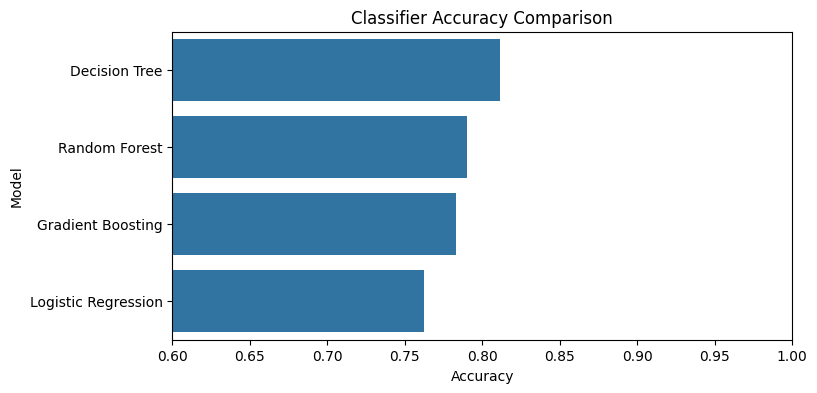

In [14]:
plt.figure(figsize=(8,4))
sns.barplot(data=results_clf.sort_values('Accuracy', ascending=False), x='Accuracy', y='Model')
plt.title('Classifier Accuracy Comparison')
plt.xlim(0.6, 1.0)
plt.show()

### Try It Yourself!

**Exercises:**
1. Modify `drop_first=False` in the One-Hot encoding cell and see if it hurts Logistic Regression.
2. Change `max_depth` in the Random Forest to `None` and compare the Train and Test accuracy to check for overfitting.